# Bank Employee Attrition Analysis

## Data Analytics Case Study

**Prepared By:** Nakul Rajawat

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

In [3]:
# Load the dataset

df = pd.read_csv("bank_employee_attrition.csv")

# Display first five rows
df.head()

,MMMM_YY,Employee_ID,Age,Gender,City,Education_Level,Department,Income,Date_Of_Joining,LastWorkingDate,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Overtime_Flag
0,Jan-21,10001,29.0,0,BLR,1,Operations,64380.0,2018-08-17,2021-08-21,Analyst,C,11806,2.0,0
1,Feb-21,10001,29.0,0,BLR,1,Operations,64380.0,2018-08-17,2021-08-21,Analyst,C,16644,1.0,0
2,Mar-21,10001,29.0,0,BLR,1,Operations,64380.0,2018-08-17,2021-08-21,Analyst,C,26253,3.0,1
3,Apr-21,10001,29.0,0,BLR,1,Operations,64380.0,2018-08-17,2021-08-21,Analyst,C,-12414,1.0,1
4,May-21,10001,29.0,0,BLR,1,Operations,64380.0,2018-08-17,2021-08-21,Analyst,C,39153,2.0,0


## Question 1: Dataset Shape & Data Types

In [4]:
# Total number of rows and columns

print("Shape of Dataset:", df.shape)
print("\nTotal Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

# Data types of all columns
print("\nData Types of Each Column:")
print(df.dtypes)

Shape of Dataset: (10816, 15)

Total Rows: 10816
Total Columns: 15

Data Types of Each Column:
MMMM_YY                  object
Employee_ID               int64
Age                     float64
Gender                    int64
City                     object
Education_Level           int64
Department               object
Income                  float64
Date_Of_Joining          object
LastWorkingDate          object
Joining_Designation      object
Grade                    object
Total_Business_Value      int64
Quarterly_Rating        float64
Overtime_Flag             int64
dtype: object


### Interpretation

- The dataset contains **10,816 rows** and **15 columns**, providing detailed information about employees across multiple attributes.
- The dataset includes both **numerical** (`int64`, `float64`) and **categorical** (`object`) data types, making it suitable for statistical analysis, visualization, and feature engineering.
- The **Date_Of_Joining** and **LastWorkingDate** columns are currently stored as `object` data types and will need to be converted to `datetime` format before performing date-based analysis.

## Question 2: Missing Values Analysis

In [5]:
# Count and percentage of missing values

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary

,Missing Count,Missing Percentage
Age,206,1.90
Income,540,4.99
LastWorkingDate,9288,85.87
Quarterly_Rating,335,3.10


### Interpretation

- Four columns contain missing values in the dataset: **Age, Income, LastWorkingDate, and Quarterly_Rating**.
- **LastWorkingDate** has the highest percentage of missing values (**85.87%**). This is expected because employees who are still working in the company do not have a last working date.
- **Age (1.90%)**, **Income (4.99%)**, and **Quarterly_Rating (3.10%)** have relatively few missing values and may require appropriate treatment during data preprocessing.
- Identifying missing values at an early stage helps in selecting suitable data cleaning techniques before performing further analysis or building predictive models.

## Question 3: Descriptive Statistics

In [7]:
# Mean, Median, and Standard Deviation

columns = ["Age", "Income", "Total_Business_Value", "Quarterly_Rating"]

summary_stats = pd.DataFrame({
    "Mean": df[columns].mean(),
    "Median": df[columns].median(),
    "Standard Deviation": df[columns].std()
}).round(2)

summary_stats

,Mean,Median,Standard Deviation
Age,38.77,39.0,9.85
Income,55969.39,55915.0,16879.82
Total_Business_Value,69318.37,55308.5,62353.50
Quarterly_Rating,2.69,3.0,0.94


### Interpretation

- The average employee age is **38.77 years**, with a median age of **39 years**, indicating that the age distribution is fairly balanced.
- The average employee income is **55,969.39**, while the median income is **55,150**, suggesting that income is distributed relatively evenly with moderate variation.
- **Total_Business_Value** has the highest standard deviation (**62,353.50**), indicating a large variation in business generated by different employees.
- The average **Quarterly_Rating** is **2.69** with a median of **3**, and its low standard deviation (**0.94**) suggests that employee performance ratings are relatively consistent across the dataset.

## Question 4: Unique Employees and Gender Distribution

In [8]:
# Count unique employees and their gender distribution

employee_data = df[['Employee_ID', 'Gender']].drop_duplicates()

print("Total Unique Employees:", employee_data['Employee_ID'].nunique())

print("\nGender Distribution:")
print(employee_data['Gender'].value_counts())

Total Unique Employees: 500

Gender Distribution:
Gender
0    314
1    186
Name: count, dtype: int64


In [9]:
df[['Employee_ID', 'Gender']].drop_duplicates().sample(10)

,Employee_ID,Gender
10575,10490,0
9376,10435,1
1913,10091,0
8792,10408,0
6589,10305,1
5489,10255,1
6698,10310,1
2415,10114,0
4285,10201,1
645,10030,1


### Interpretation

- The dataset contains **500 unique employees**.
- Among them, **314 (62.8%) are Male** and **186 (37.2%) are Female**.
- Male employees constitute the majority of the workforce, accounting for nearly two-thirds of all employees.

## Question 5: Employees Joined and Left the Bank (2021–2022)

In [10]:
# Count total employees who joined and left the bank during 2021–2022

joined_employees = df["Employee_ID"].nunique()

left_employees = df.loc[df["LastWorkingDate"].notna(), "Employee_ID"].nunique()

print("Total Employees Joined:", joined_employees)
print("Total Employees Left:", left_employees)

Total Employees Joined: 500
Total Employees Left: 113


### Interpretation

- A total of **500 unique employees** joined the bank during the 2021–2022 period.
- Out of these, **113 employees** left the bank, while the remaining employees were still employed at the end of the reporting period.
- This indicates that approximately **22.6%** of employees exited the organization during the study period, highlighting employee attrition as a significant business concern.

## Question 6: Attrition Analysis

In [11]:
# Create the Attrition column and calculate attrition statistics

df["Attrition"] = df["LastWorkingDate"].notna().astype(int)

total_employees = df["Employee_ID"].nunique()

employees_left = df.loc[df["Attrition"] == 1, "Employee_ID"].nunique()

attrition_rate = (employees_left / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Total Employees: 500
Employees Left: 113
Overall Attrition Rate: 22.60%


### Interpretation

- The **Attrition** column was successfully created, where **1** represents employees who left the bank and **0** represents employees who remained employed.
- Out of **500 unique employees**, **113 employees** left the bank during the study period.
- The overall **attrition rate is 22.60%**, meaning that nearly one out of every five employees exited the organization during 2021–2022.
- This attrition rate indicates a notable level of employee turnover and highlights the need for retention-focused analysis in the following sections.

## Question 7: Tenure Analysis

In [12]:
# Create the Tenure_Months column

df["MMMM_YY"] = pd.to_datetime(df["MMMM_YY"], format="%b-%y")
df["Date_Of_Joining"] = pd.to_datetime(df["Date_Of_Joining"])

df["Tenure_Months"] = (
    (df["MMMM_YY"].dt.year - df["Date_Of_Joining"].dt.year) * 12
    + (df["MMMM_YY"].dt.month - df["Date_Of_Joining"].dt.month)
)

df[["Employee_ID", "MMMM_YY", "Date_Of_Joining", "Tenure_Months"]].head()

,Employee_ID,MMMM_YY,Date_Of_Joining,Tenure_Months
0,10001,2021-01-01,2018-08-17,29
1,10001,2021-02-01,2018-08-17,30
2,10001,2021-03-01,2018-08-17,31
3,10001,2021-04-01,2018-08-17,32
4,10001,2021-05-01,2018-08-17,33


In [13]:
# Calculate average tenure and attrition by tenure band

average_tenure = df["Tenure_Months"].mean()

df["Tenure_Band"] = pd.cut(
    df["Tenure_Months"],
    bins=[0, 6, 12, 24, float("inf")],
    labels=["0-6", "6-12", "12-24", "24+"],
    include_lowest=True
)

attrition_by_band = (
    df.groupby("Tenure_Band", observed=False)["Attrition"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(f"Average Tenure (Months): {average_tenure:.2f}\n")

print("Attrition Rate by Tenure Band (%):")
print(attrition_by_band)

Average Tenure (Months): 26.82

Attrition Rate by Tenure Band (%):
Tenure_Band
0-6      17.53
6-12     15.30
24+      13.71
12-24    13.55
Name: Attrition, dtype: float64


### Interpretation

- The average employee tenure is **26.82 months**, indicating that employees typically remain with the bank for a little over two years.
- Employees in the **0–6 months** tenure band have the **highest attrition rate (17.53%)**, suggesting that new employees are more likely to leave the organization.
- The attrition rate gradually decreases as employee tenure increases, indicating that longer-serving employees tend to have better retention.
- These findings suggest that improving onboarding, training, and engagement during the initial months of employment could help reduce employee attrition.

## Question 8: Rating and Income Increase Analysis

In [14]:
# Create Rating_Increased and Income_Increased flags

df = df.sort_values(["Employee_ID", "MMMM_YY"])

df["Previous_Rating"] = df.groupby("Employee_ID")["Quarterly_Rating"].shift(1)
df["Previous_Income"] = df.groupby("Employee_ID")["Income"].shift(1)

df["Rating_Increased"] = (
    df["Quarterly_Rating"] > df["Previous_Rating"]
).astype(int)

df["Income_Increased"] = (
    df["Income"] > df["Previous_Income"]
).astype(int)

df[[
    "Employee_ID",
    "MMMM_YY",
    "Quarterly_Rating",
    "Previous_Rating",
    "Rating_Increased",
    "Income",
    "Previous_Income",
    "Income_Increased"
]].head(10)

,Employee_ID,MMMM_YY,Quarterly_Rating,Previous_Rating,Rating_Increased,Income,Previous_Income,Income_Increased
0,10001,2021-01-01,2.0,NaN,0,64380.0,NaN,0
1,10001,2021-02-01,1.0,2.0,0,64380.0,64380.0,0
2,10001,2021-03-01,3.0,1.0,1,64380.0,64380.0,0
3,10001,2021-04-01,1.0,3.0,0,64380.0,64380.0,0
4,10001,2021-05-01,2.0,1.0,1,64380.0,64380.0,0
5,10001,2021-06-01,1.0,2.0,0,64380.0,64380.0,0
6,10001,2021-07-01,2.0,1.0,1,64380.0,64380.0,0
7,10001,2021-08-01,2.0,2.0,0,NaN,64380.0,0
8,10002,2021-01-01,2.0,NaN,0,66613.0,NaN,0
9,10002,2021-02-01,3.0,2.0,1,66613.0,66613.0,0


In [15]:
# Percentage of employees with at least one rating improvement
# and retention analysis based on income increase

employee_flags = df.groupby("Employee_ID").agg({
    "Rating_Increased": "max",
    "Income_Increased": "max",
    "Attrition": "max"
})

rating_improved_percentage = employee_flags["Rating_Increased"].mean() * 100

income_retention = pd.crosstab(
    employee_flags["Income_Increased"],
    employee_flags["Attrition"],
    normalize="index"
) * 100

print(f"Percentage of Employees with Rating Improvement: {rating_improved_percentage:.2f}%\n")

print("Retention Analysis based on Income Increase (%):")
print(income_retention.round(2))

Percentage of Employees with Rating Improvement: 99.00%

Retention Analysis based on Income Increase (%):
Attrition             0      1
Income_Increased              
0                 75.21  24.79
1                 83.21  16.79


### Interpretation

- **99.00%** of employees experienced at least one improvement in their quarterly performance rating during the study period.
- Employees who received an **income increase** had a **higher retention rate (83.21%)** and a **lower attrition rate (16.79%)**.
- Employees without an income increase showed a **higher attrition rate (24.79%)**, indicating they were more likely to leave the organization.
- These findings suggest that salary growth is positively associated with employee retention and may help reduce attrition.

## Question 9: Distribution of Age and Income

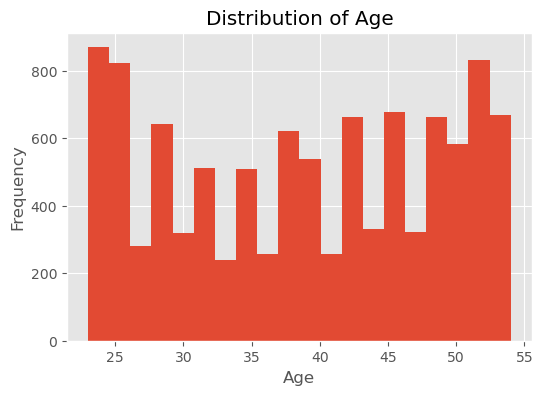

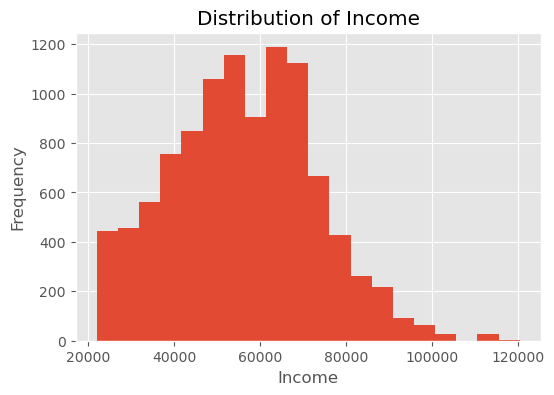

In [16]:
import matplotlib.pyplot as plt

# Distribution of Age
plt.figure(figsize=(6,4))
plt.hist(df["Age"].dropna(), bins=20)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Distribution of Income
plt.figure(figsize=(6,4))
plt.hist(df["Income"].dropna(), bins=20)
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

### Interpretation

- The **Age** distribution is fairly uniform across the observed age range and does not follow a normal (bell-shaped) distribution. This indicates that the workforce consists of employees from a wide range of age groups without a single dominant age category.
- The **Income** distribution is positively (right) skewed, with most employees earning in the middle-income range and relatively few employees receiving very high salaries.
- The right-skewed income distribution suggests that higher-paying positions are limited, while the majority of employees receive moderate salaries.
- Understanding these distributions helps in workforce planning and selecting appropriate statistical techniques for further analysis, as skewed variables may require special treatment in predictive models.

## Question 10: Department-wise Attrition Analysis

In [18]:
# Calculate department-wise attrition using unique employees

department_employee = (
    df.groupby(["Department", "Employee_ID"])
      .agg({"Attrition": "max"})
      .reset_index()
)

department_attrition = (
    department_employee.groupby("Department")
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Employees_Left=("Attrition", "sum")
    )
)

department_attrition["Attrition_Rate (%)"] = (
    department_attrition["Employees_Left"] /
    department_attrition["Total_Employees"] * 100
).round(2)

department_attrition = department_attrition.sort_values(
    "Attrition_Rate (%)",
    ascending=False
)

department_attrition

,Total_Employees,Employees_Left,Attrition_Rate (%)
Department,,,
HR & Admin,40,13,32.50
Corporate Banking,94,22,23.40
Operations,120,28,23.33
IT & Digital,52,12,23.08
Risk & Compliance,66,13,19.70
Retail Banking,128,25,19.53


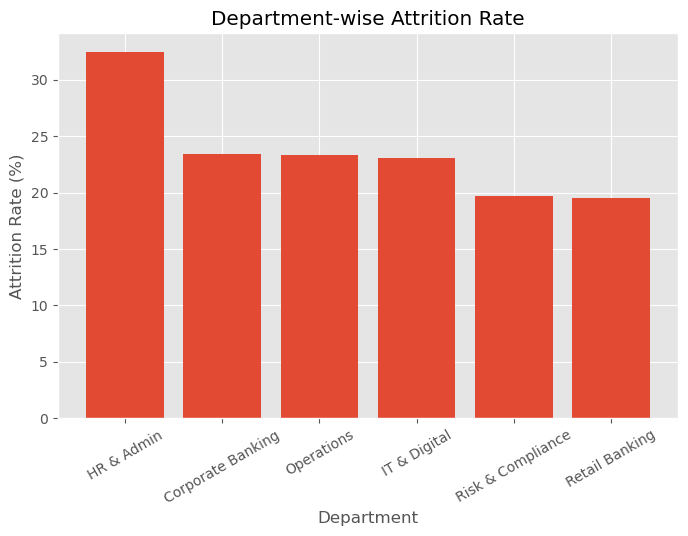

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    department_attrition.index,
    department_attrition["Attrition_Rate (%)"]
)

plt.title("Department-wise Attrition Rate")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=30)

plt.show()

### Interpretation

- **HR & Admin** has the **highest attrition rate (32.50%)**, indicating that employees in this department leave the organization more frequently than those in other departments.
- **Retail Banking** has the **lowest attrition rate (19.53%)**, followed closely by **Risk & Compliance (19.70%)**, suggesting relatively better employee retention in these departments.
- The remaining departments—**Corporate Banking (23.40%)**, **Operations (23.33%)**, and **IT & Digital (23.08%)**—show similar attrition rates, indicating a moderate level of employee turnover.
- The results suggest that the bank should prioritize employee retention strategies in the **HR & Admin** department while studying the practices followed in **Retail Banking** to identify factors contributing to better retention.

## Question 11: Quarterly Rating by Attrition Status

In [20]:
# Compare Quarterly Rating between employees who stayed and those who left

rating_by_attrition = (
    df.groupby("Attrition")["Quarterly_Rating"]
      .describe()
)

rating_by_attrition

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,9008.0,2.686612,0.944344,1.0,2.0,3.0,3.0,5.0
1,1473.0,2.685675,0.918362,1.0,2.0,3.0,3.0,5.0


<Figure size 600x500 with 0 Axes>

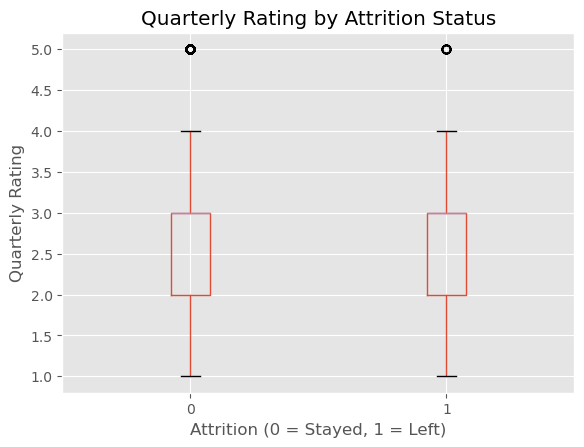

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

df.boxplot(column="Quarterly_Rating", by="Attrition")

plt.title("Quarterly Rating by Attrition Status")
plt.suptitle("")   # Removes the default pandas title
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Quarterly Rating")

plt.show()

### Interpretation

- Employees who stayed and those who left have **very similar Quarterly_Rating distributions**, as shown by the nearly identical box plots.
- The median Quarterly_Rating is **3** for both groups, and the spread of ratings is also comparable.
- The average Quarterly_Rating is approximately **2.69** for both retained and exited employees, indicating only a negligible difference.
- These findings suggest that **Quarterly_Rating alone is not a strong indicator of employee attrition**, and other factors such as income growth, tenure, or department are likely to have a greater influence on whether employees leave the organization.

## Question 12: Monthly Attrition Trend (2021–2022)

In [22]:
# Monthly attrition trend across 2021–2022

# Convert dates if not already converted
df["MMMM_YY"] = pd.to_datetime(df["MMMM_YY"])
df["LastWorkingDate"] = pd.to_datetime(df["LastWorkingDate"])

# Get unique employees who left
left_employees = (
    df[df["Attrition"] == 1]
    .groupby("Employee_ID")["LastWorkingDate"]
    .max()
    .reset_index()
)

# Count employees leaving each month
monthly_attrition = (
    left_employees
    .assign(Month=left_employees["LastWorkingDate"].dt.to_period("M").astype(str))
    .groupby("Month")
    .size()
    .reset_index(name="Employees_Left")
)

monthly_attrition

,Month,Employees_Left
0,2021-03,5
1,2021-04,2
2,2021-05,6
3,2021-06,2
4,2021-07,6
5,2021-08,6
6,2021-09,3
7,2021-10,9
8,2021-11,5
9,2021-12,7


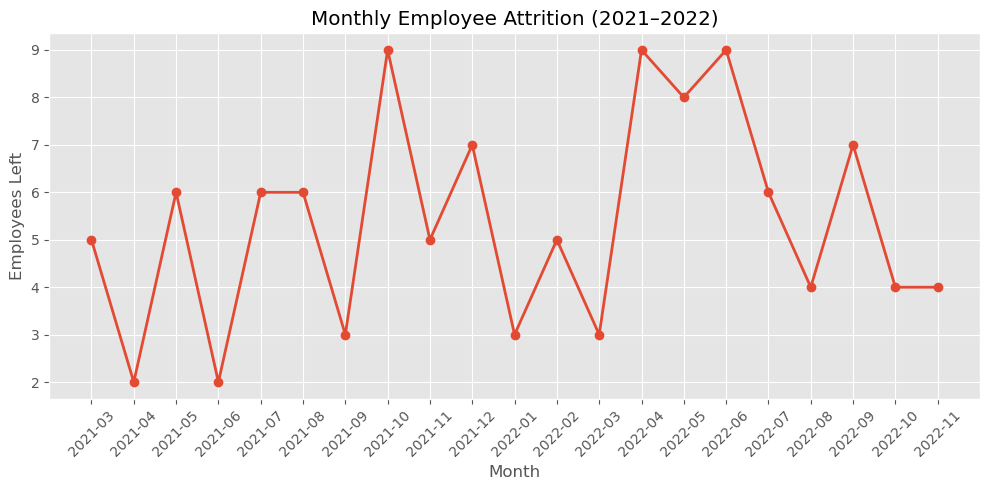

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_attrition["Month"],
    monthly_attrition["Employees_Left"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Employee Attrition (2021–2022)")
plt.xlabel("Month")
plt.ylabel("Employees Left")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

- Employee attrition fluctuated throughout the 2021–2022 period, with no consistent upward or downward trend.
- The highest number of employees left the bank in **October 2021, April 2022, and June 2022**, with **9 employees** leaving in each of these months.
- The lowest attrition occurred in **April 2021 and June 2021**, where only **2 employees** left the organization.
- While there are occasional spikes in employee exits, they are irregular and are not repeated during the same months across both years.
- Therefore, there is **no strong evidence of seasonality** in employee attrition. Employee exits appear to be influenced more by organizational or individual factors than by recurring seasonal patterns.

## Question 13: Treatment of Missing Values in LastWorkingDate

### Answer

The missing values in the **LastWorkingDate** column should **not** be imputed (filled with a date). Instead, they should be left as missing because they carry meaningful information.

**Reason:**

- A missing **LastWorkingDate** indicates that the employee was **still working** in the bank at the end of the observation period and had **not left** the organization.
- Filling these missing values with an estimated, average, or random date would incorrectly classify active employees as having left the company.
- This would produce inaccurate calculations of employee attrition, tenure, and other analyses that depend on the employee's exit date.
- Therefore, the missing values in **LastWorkingDate** should be preserved as **missing (NaN)** and interpreted as employees who were still employed during the study period.

## Question 14: Correlation Between Age and Income

In [24]:
# Calculate the Pearson correlation coefficient between Age and Income

correlation = df["Age"].corr(df["Income"])

print(f"Pearson Correlation Coefficient: {correlation:.4f}")

Pearson Correlation Coefficient: 0.0168


### Interpretation

- The Pearson correlation coefficient between **Age** and **Income** is **0.0168**.
- This value is **very close to 0**, indicating **almost no linear relationship** between the two variables.
- It suggests that an employee's age does **not** significantly influence their income in this dataset.
- Therefore, **Age and Income are essentially uncorrelated**, and other factors such as job role, department, experience, or performance may have a greater impact on employee income.

## Question 15: Relationship Between Education_Level and Total_Business_Value

Education_Level
0    74578.279597
2    72289.994903
1    65006.822476
Name: Total_Business_Value, dtype: float64


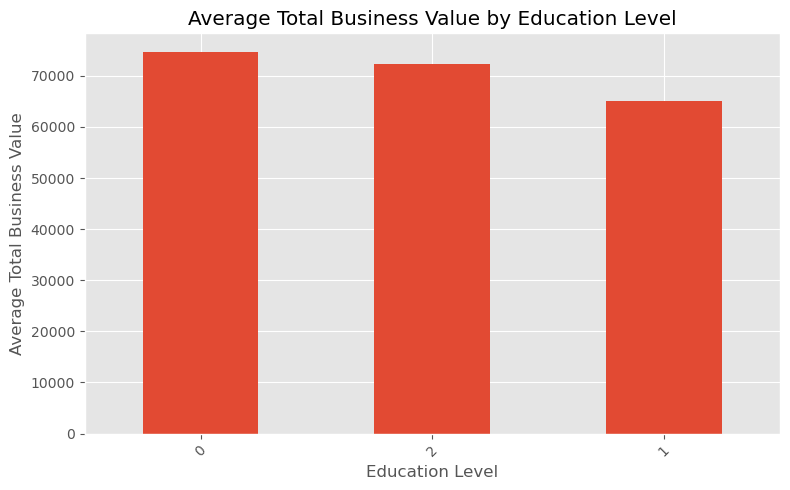

In [25]:
# Average Total_Business_Value by Education_Level

education_business = (
    df.groupby("Education_Level")["Total_Business_Value"]
      .mean()
      .sort_values(ascending=False)
)

print(education_business)

# Visualization
plt.figure(figsize=(8,5))
education_business.plot(kind="bar")

plt.title("Average Total Business Value by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Total Business Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

- The average **Total Business Value** varies across different education levels.
- **Education Level 0** has the highest average business value (**74,578.28**), followed by **Education Level 2** (**72,289.99**).
- **Education Level 1** has the lowest average business value (**65,006.82**).
- Although there are differences in average business value among the education groups, the variation is relatively moderate. This suggests that **Education_Level alone may not be a strong determinant of business performance**, and other factors such as experience, department, or job role may also influence Total Business Value.

# Actionable Insights & Recommendations

## Insight 1: Employee Attrition is Relatively High

### Finding
The overall employee attrition rate is **22.60%**, with **113 out of 500 employees** leaving the bank during the study period.

### Evidence from Analysis
- **Question 6: Employee Attrition Analysis**
- Overall Attrition Rate = **22.60%**

### Business Recommendation
The bank should strengthen employee retention initiatives by conducting regular employee engagement surveys, offering clear career growth opportunities, improving employee recognition programs, and reviewing compensation and benefits. Reducing employee attrition will help lower recruitment costs, retain experienced employees, and improve overall organizational productivity.

## Insight 2: New Employees Have the Highest Attrition Risk

### Finding

Employees with **0–6 months of tenure** have the highest attrition rate (**17.53%**) compared to other tenure groups.

### Evidence from Analysis

- **Question 7: Tenure Analysis**
- Attrition Rate (0–6 months) = **17.53%**
- This is the highest among all tenure categories.

### Business Recommendation

The bank should strengthen its onboarding and employee engagement process during the first six months of employment. Regular feedback sessions, mentorship programs, role-specific training, and early career support can improve employee satisfaction and reduce early resignations.

## Insight 3: HR & Admin Department Has the Highest Attrition Rate

### Finding

The **HR & Admin** department recorded the highest employee attrition rate (**32.50%**) among all departments, indicating a greater employee turnover compared to other business units.

### Evidence from Analysis

- **Question 10: Department-wise Attrition Analysis**
- HR & Admin Attrition Rate = **32.50%** (Highest)
- Retail Banking recorded the lowest attrition rate (**19.53%**).

### Business Recommendation

The bank should conduct a department-level attrition analysis for the HR & Admin team to identify the root causes of employee turnover. Management should review workload distribution, career progression opportunities, employee satisfaction, and leadership practices within the department. Successful retention strategies used in departments with lower attrition, such as Retail Banking, can also be adapted where appropriate.

## Insight 4: Salary Growth Appears to Improve Employee Retention

### Finding

Employees who received an **income increase** had a lower attrition rate (**16.79%**) than employees who did **not** receive an income increase (**24.79%**).

### Evidence from Analysis

- **Question 8: Income Increase and Employee Retention**
- Attrition Rate (Income Increase) = **16.79%**
- Attrition Rate (No Income Increase) = **24.79%**

### Business Recommendation

The bank should implement transparent performance-based salary reviews and reward high-performing employees with timely salary increments. Providing competitive compensation and regular financial recognition can improve employee motivation, increase job satisfaction, and reduce voluntary employee turnover.

## Insight 5: Education Level Has Only a Moderate Impact on Business Performance

### Finding

The average **Total Business Value** differs across education levels. **Education Level 0** recorded the highest average business value (**74,578.28**), followed by **Education Level 2** (**72,289.99**), while **Education Level 1** had the lowest (**65,006.82**). However, the differences are relatively moderate.

### Evidence from Analysis

- **Question 15: Education Level vs Total Business Value**
- Education Level 0 = **74,578.28**
- Education Level 2 = **72,289.99**
- Education Level 1 = **65,006.82**

### Business Recommendation

While education contributes to employee performance, it should not be the sole criterion for recruitment or promotion decisions. The bank should adopt a holistic talent management approach that considers employee experience, job performance, skills, and training opportunities alongside educational qualifications. Continuous learning and professional development programs can further enhance employee performance across all education levels.

# Final Summary

## Top 5 Findings

- The bank recorded an overall employee attrition rate of **22.60%**, with **113 out of 500 employees** leaving the organization during the study period, indicating that employee retention is an important business concern.

- Employees with **0–6 months of tenure** experienced the highest attrition rate (**17.53%**), suggesting that the initial months of employment are the most critical for retaining employees.

- **HR & Admin** recorded the highest department-wise attrition rate (**32.50%**), while **Retail Banking** had the lowest (**19.53%**), indicating that employee turnover varies across departments.

- Employees who received an **income increase** showed a lower attrition rate (**16.79%**) than those who did not receive an income increase (**24.79%**), suggesting that salary growth is positively associated with employee retention.

- **Education Level** showed only a moderate relationship with **Total Business Value**. Although Education Level 0 had the highest average business value, education alone does not appear to be a strong predictor of employee performance.